## 30.2) Detecção de outliers

ambiente anaconda Udemy

comando linux:

 find -name 'census.csv'
 
resposta

./Machine_Learning_Udemy/24-Dados_desbalanceados/census.csv

find -name 'credit'

sem nada

$ find -name '*credit*'$

./Machine_Learning_Udemy/27-Deteccao_de_outliers/credit_data.csv

./Machine_Learning_Udemy/2-3-Classificacao/credit_risk_dataset.csv



# Detecção de outliers

## Boxplot

In [12]:
import pandas as pd

In [13]:
base_credit = pd.read_csv('credit_data.csv')
base_credit.tail()

,clientid,income,age,loan,default
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0
1999,2000,69436.579552,56.152617,7378.833599,0


In [14]:
base_credit_2 = pd.read_csv('../../Machine_Learning_Udemy/2-3-Classificacao/credit_risk_dataset.csv')
base_credit_2.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


default => 0 cliente paga e 1 cliente não paga o imprestimo. 

verificar os dados faltantes

In [15]:
base_credit.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

3 dados da idade que não foi preenchida. 

apagaremos os dados nulos, para não ocorrer erro nos processos. 

In [16]:
base_credit.loc[base_credit['age'].isnull()]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [17]:
base_credit.dropna(inplace=True)

verificamos que não há nenhum registro nulo nos processos

In [19]:
base_credit.isnull().sum()

clientid    0
income      0
age         0
loan        0
default     0
dtype: int64

# Outliers idade


In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

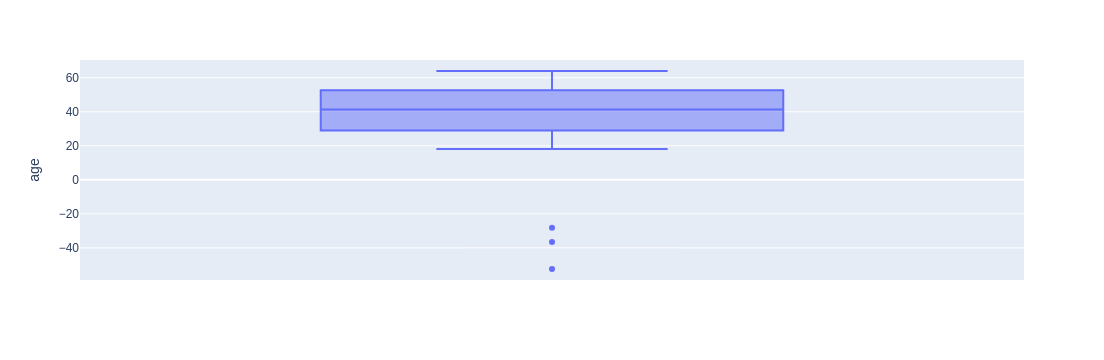

In [22]:
# Outliers idade
grafico = px.box(base_credit, y = 'age')
grafico.show()

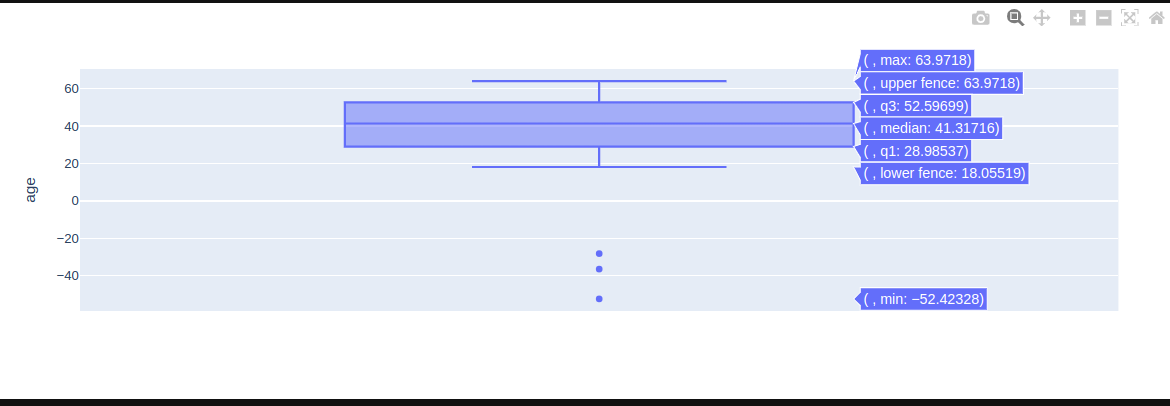

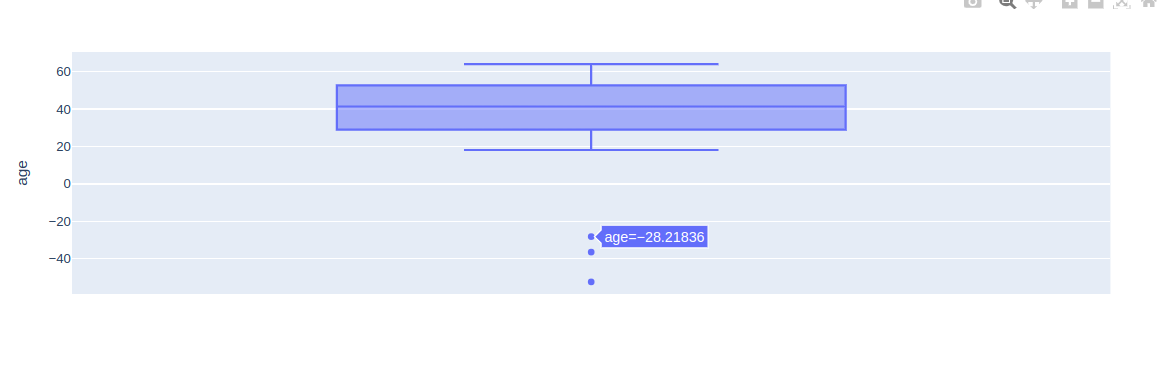

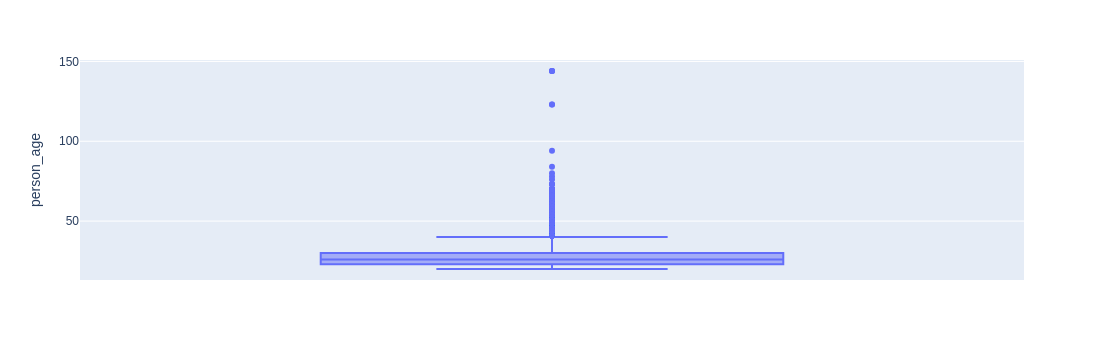

In [24]:
# Outliers idade
grafico = px.box(base_credit_2, y = 'person_age')
grafico.show()

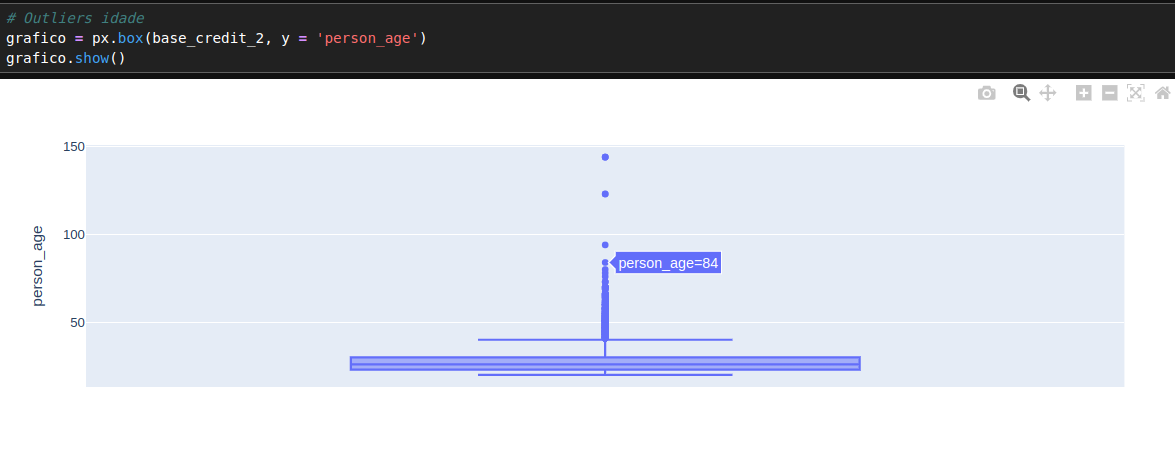

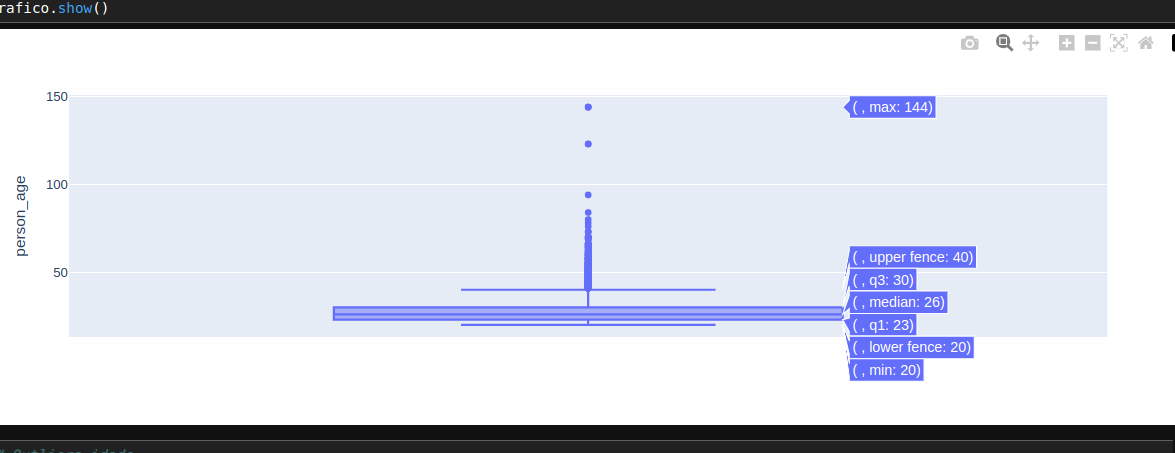

### a mediana é o valor que está no meio dos dados, diferente da média.

In [26]:
len(base_credit)

1997

In [29]:
# saber o valor que está na mediana

In [28]:
len(base_credit)/2

998.5

In [27]:
1997 / 2

998.5

In [34]:
base_credit_mediana = base_credit.reset_index(drop=True)
print()
#Primeiro pegamos o rótulo/ID do índice
indice_alvo = base_credit_mediana.index[998]
print('indice')
print(indice_alvo)
# Buscamos a linha inteira por esse rótulo
print()
linha = base_credit_mediana.loc[indice_alvo]
print(linha)


indice
998

clientid     1002.000000
income      62422.203789
age            32.145221
loan         2841.633423
default         0.000000
Name: 998, dtype: float64


In [35]:
linha = base_credit_mediana.loc[999]
print(linha)

clientid     1003.000000
income      63166.994955
age            56.510040
loan         4058.789534
default         0.000000
Name: 999, dtype: float64


In [37]:
base_credit.loc[999]

clientid     1000.000000
income      62165.861186
age            19.602543
loan         4739.948954
default         0.000000
Name: 999, dtype: float64

In [38]:
base_credit.loc[998]

clientid      999.000000
income      36192.149452
age            21.402403
loan         7236.173930
default         1.000000
Name: 998, dtype: float64

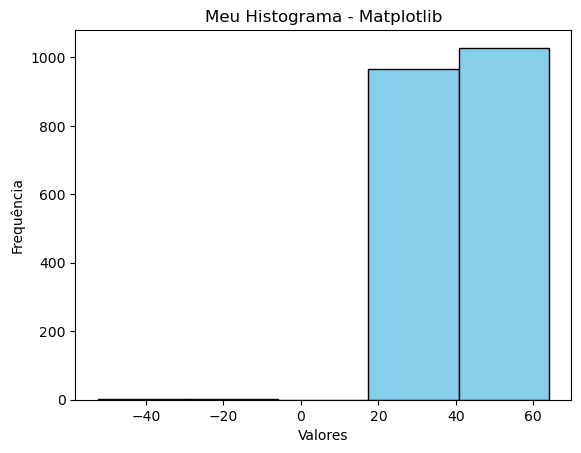

In [41]:
plt.hist(base_credit['age'], bins=5, color='skyblue', edgecolor='black')
plt.title('Meu Histograma - Matplotlib')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

mediana ~ 41

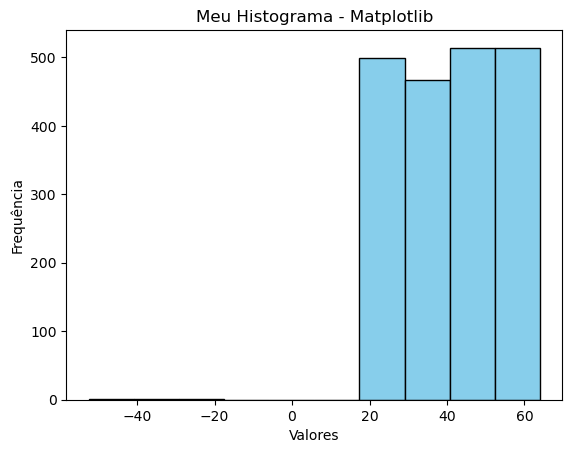

In [42]:
plt.hist(base_credit['age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Meu Histograma - Matplotlib')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.show()

primeiro quartil e o terceiro quartil q1 e q3,

q1 idade em que está em 25% dos registros.

e o q3 idade que está na posição dos 75% dos registros.

pontos fora são os ouliers:

### dados fora do upper fence e lower fence. 

In [43]:
# Outliers idade
outliers_age = base_credit[base_credit['age'] < -20]
outliers_age

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


considerados outliers

In [44]:
outliers_age = base_credit[base_credit['age'] < 0]
outliers_age

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


Identificar ou detectar fraude da empresa.

fraude em cartão de crédito, seleciona as transações que saem do padrão, indicando ao setor responsável para que o stero faça a análise para verificar de fato se fogem realmente do padrão.  

### Outliers loan / dívida

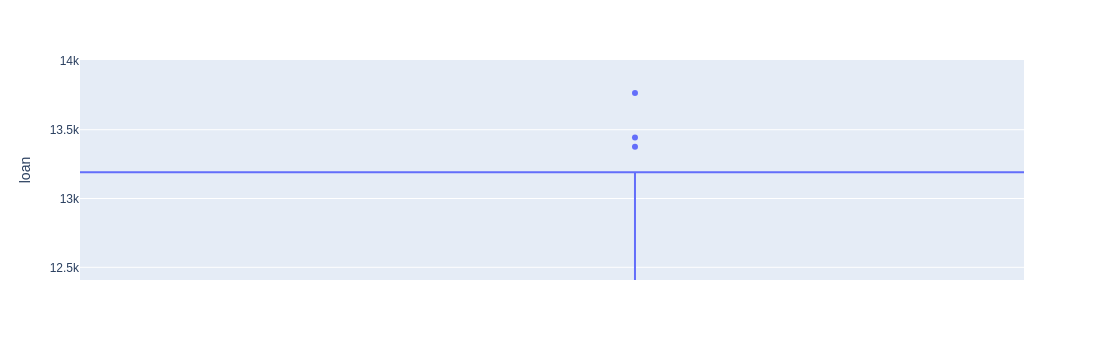

In [45]:
# Outliers loan
grafico = px.box(base_credit, y='loan')
grafico.show()

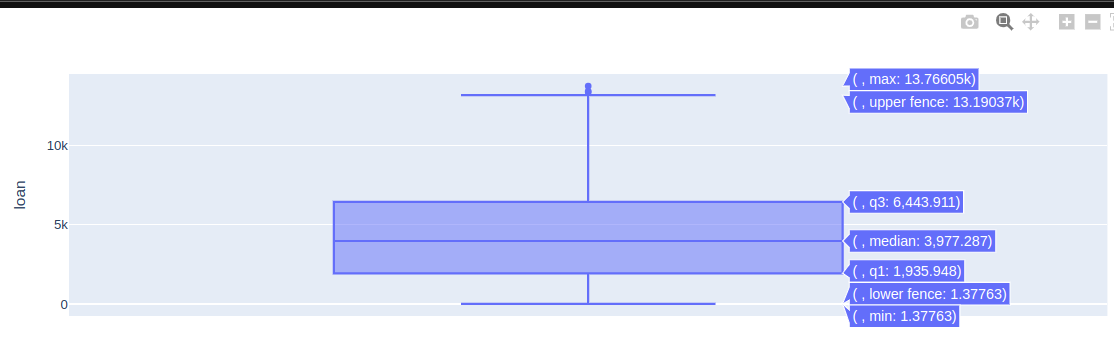

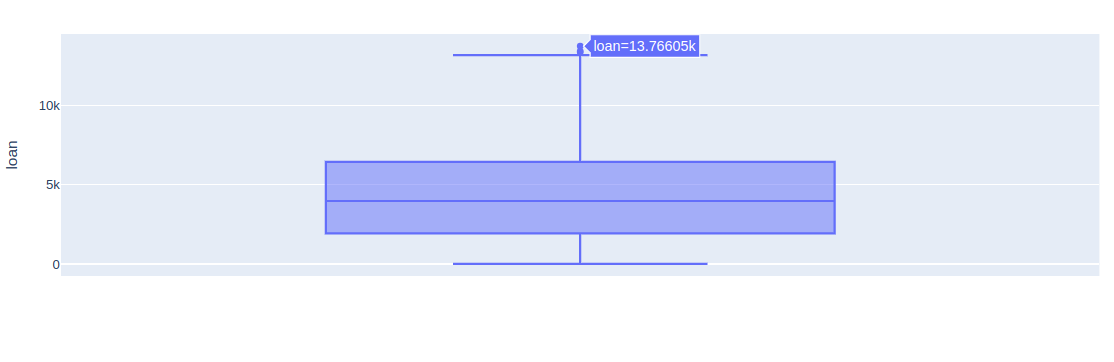

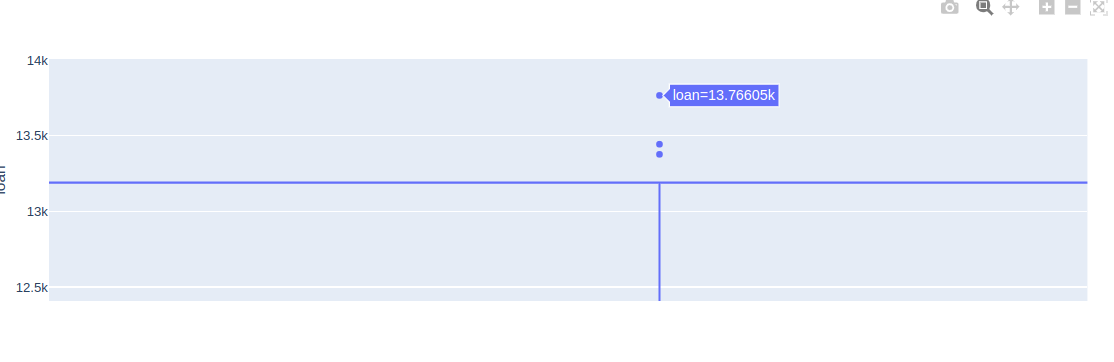

inserir os dados ao setor responsável

In [47]:
outliers_loan = base_credit[base_credit['loan'] > 13300] # DE ACORDO COM A VISUALIZAÇÃO box plot
outliers_loan

,clientid,income,age,loan,default
1378,1379,69755.320163,44.543682,13766.051239,0
1584,1585,67289.585683,26.727400,13376.797706,1
1801,1802,67802.694456,49.037987,13443.473176,0


In [54]:
outliers_loan = base_credit[base_credit['loan'] > 13190] # DE ACORDO COM A VISUALIZAÇÃO box plot, teste
outliers_loan

,clientid,income,age,loan,default
1050,1051,69456.567771,48.053557,13190.365886,0
1378,1379,69755.320163,44.543682,13766.051239,0
1584,1585,67289.585683,26.727400,13376.797706,1
1801,1802,67802.694456,49.037987,13443.473176,0


In [55]:
outliers_loan = base_credit[base_credit['loan'] > 13191] # DE ACORDO COM A VISUALIZAÇÃO box plot1
outliers_loan

,clientid,income,age,loan,default
1378,1379,69755.320163,44.543682,13766.051239,0
1584,1585,67289.585683,26.727400,13376.797706,1
1801,1802,67802.694456,49.037987,13443.473176,0




Outliers

- Valores anormais

- valores fora do padrão (afastados da média)

Fogem do valor da média, valores anormais, como uma variável (boxplot) 

além do gráfico de dispersão. 2 atributos juntos e identifica valor fora do padrão (outliers). Precisamos de 2 variáveis.


=> Causas

- Acaso

- Erro no preenchimento dos dados

- Fraudes. (Problemas no cartão de crédito → Fraude)


=>Tratamentos

ver que é fraude, entra em contato com o cliente

Remover o registro, problema também, pois pode remover um dado valioso. 

Não fazer nada, mas é ruim, se usarmos o modelo de regressão, atrapalha a aprendizagem de máquina,

substituir os dados, usar a média dos dados substituir no processo onde houver outliers


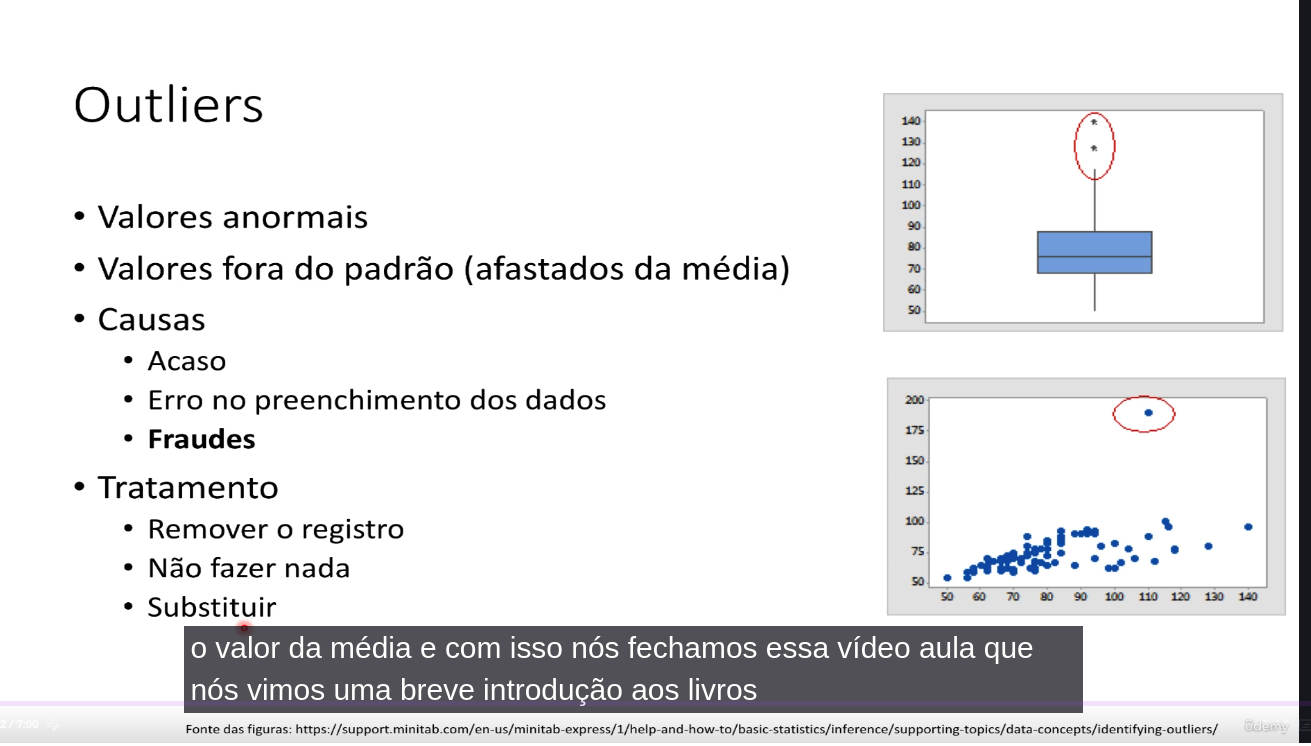